In [1]:

# Para manipulación y análisis de datos
!pip install pandas pymongo

# Para visualización de datos (gráficas)
!pip install matplotlib seaborn

# Opcional: Para análisis de sentimiento y lenguaje (muy cool para Andrés)
!pip install textblob

# Instalamos la versión CPU para ahorrar espacio
!pip install torch --index-url https://download.pytorch.org/whl/cpu
# Luego el resto
!pip install sentence-transformers scikit-learn scipy

!pip install ipympl
!pip install squarify
%matplotlib widget

Looking in indexes: https://download.pytorch.org/whl/cpu


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
import pandas as pd
import seaborn as sns
import numpy as np
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient
import pandas as pd


# Conectamos al contenedor de Mongo
client = MongoClient('mongodb://mongodb:27017/')
db = client['social_analytics']
coleccion = db['tweets']
# Convertir la colección a DataFrame
print(f"✅ Conexión restablecida. Tenemos {coleccion.count_documents({})} tweets listos para analizar.")

✅ Conexión restablecida. Tenemos 18741 tweets listos para analizar.


In [17]:

cursor = coleccion.find({}, {"_id": 0, "content": 1, "account_label": 1, "created_at": 1})

df = pd.DataFrame(list(cursor))



# 3. Verificación de seguridad para el Arquitecto

print(f"✅ DataFrame 'df' creado exitosamente.")

print(f"📊 Total de registros cargados: {len(df)}")

print(df.head()) # Esto te mostrará las primeras 5 filas para confirmar

✅ DataFrame 'df' creado exitosamente.
📊 Total de registros cargados: 18741
         account_label                                            content
0        Gamer_Project                       What the fuck just happened?
1     marthasteward295  In Canada, a streamer nicknamed Joker was raid...
2     marthasteward295  This video say a lot about nowadays society......
3  animecol300_Project  Make the perfect stew in our witch-themed deck...
4        Gamer_Project                               Jake Paul Got Caught


In [40]:
import re

from collections import Counter



# 1. Traer todos los textos de la base de datos

textos = list(coleccion.find({}, {"content": 1, "_id": 0}))



# 2. Función de limpieza rápida

def limpiar_texto(t):

    t = re.sub(r'http\S+', '', t) # Quitar links

    t = re.sub(r'[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s]', '', t) # Solo letras

    return t.lower()



# 3. Contar palabras

frecuencia_palabras = Counter()

for doc in textos:

    palabras = limpiar_texto(doc.get('content', '')).split()

    # Filtramos palabras muy cortas (artículos, preposiciones)

    palabras = [p for p in palabras if len(p) > 3] 

    frecuencia_palabras.update(palabras)



# 4. Ver las 500 más comunes

top_palabras = frecuencia_palabras.most_common(1000)

for p, f in top_palabras:

    print(f"{p}: {f}")

this: 3427
that: 2172
with: 1982
from: 1214
what: 1027
just: 989
they: 968
like: 958
have: 919
when: 879
your: 864
will: 608
after: 574
dont: 573
about: 527
time: 521
people: 509
their: 501
game: 496
more: 457
into: 442
first: 433
them: 401
video: 391
were: 385
world: 382
know: 381
good: 361
there: 360
been: 359
life: 358
years: 354
even: 346
never: 338
back: 336
only: 325
would: 322
some: 318
right: 306
here: 300
really: 296
watch: 295
today: 290
because: 288
best: 288
every: 284
make: 277
down: 275
these: 269
over: 269
little: 267
made: 266
woman: 263
most: 262
movie: 261
love: 260
while: 259
last: 257
than: 256
think: 254
look: 252
cant: 252
still: 251
where: 250
thats: 238
going: 236
youre: 235
being: 232
didnt: 224
live: 223
real: 222
before: 222
girl: 222
always: 220
which: 220
something: 220
want: 219
april: 217
take: 213
very: 213
then: 212
games: 212
need: 208
ever: 206
next: 200
work: 195
moment: 194
please: 194
much: 193
during: 187
thing: 187
getting: 186
play: 185
without:

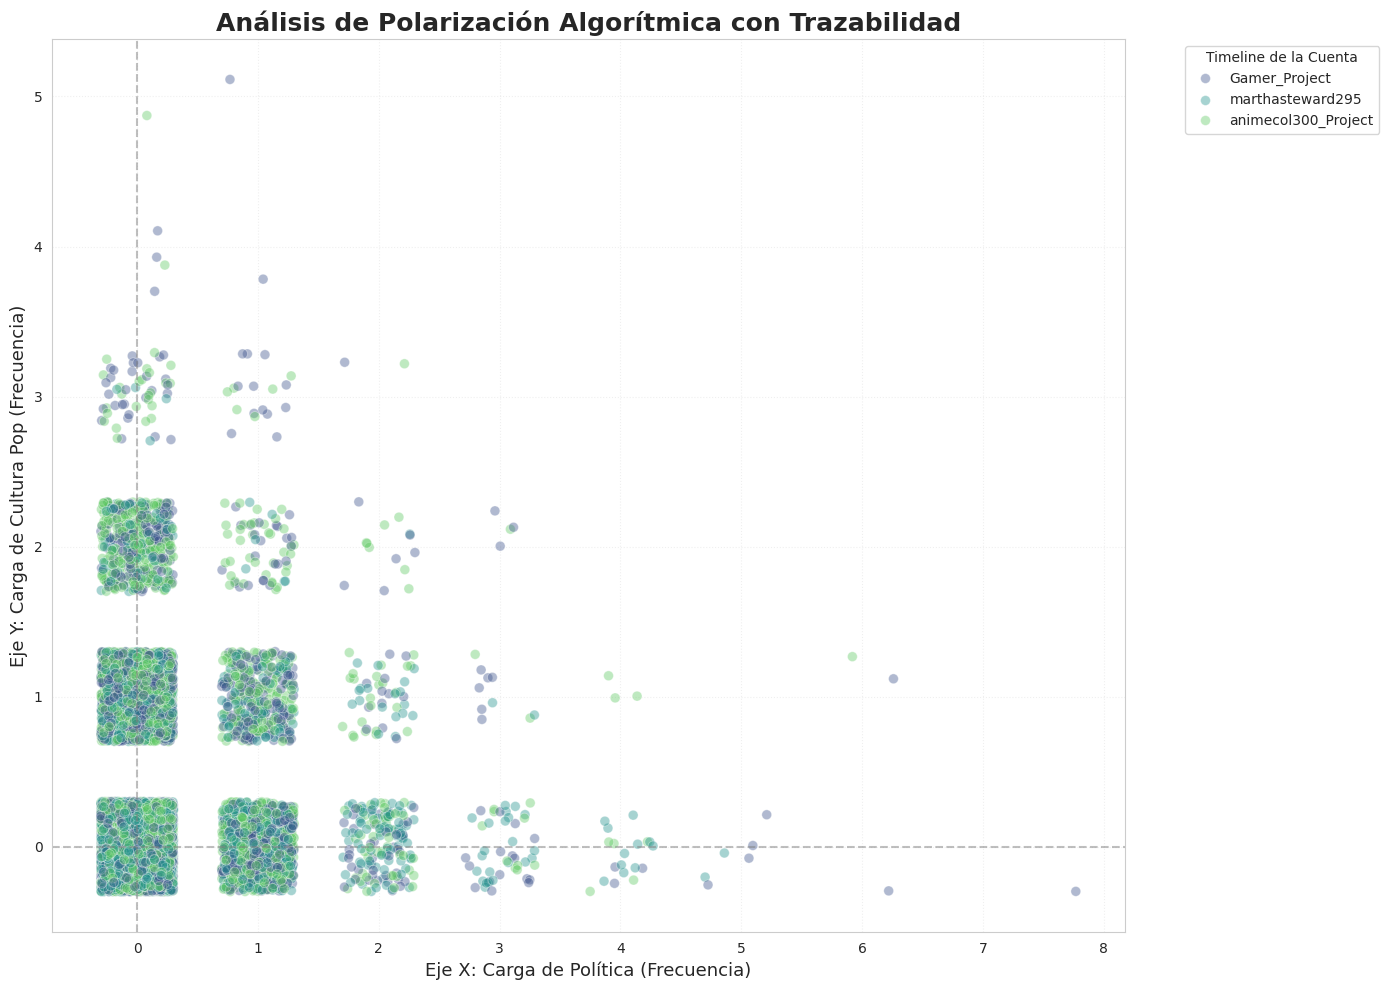


🏆 TOP 20 TWEETS POLÍTICOS CON PALABRAS DETECTADAS:


,account_label,author,content,timestamp_posted,x_pol,y_cul,x_pol_new,x_jitter,y_jitter,palabras_pol,palabras_cul,es_politico
8167,Gamer_Project,@EricLDaugh,"BREAKING: President Trump announces the Strait of Hormuz is OPENING up, and that empty ships are ""rushing"" to the US to ""LOAD UP""\n\nLFG! Big win incoming \n\n""The Fake News Media is CRAZY, or just plain CORRUPT! The United States has completely destroyed Iran’s Military,",2026-04-11T16:21:11.659253,8,0,8,7.768938,-0.298471,"[trump, president, military, iran, military, breaking, news, states]",[],True
7636,animecol300_Project,@TruthTrumpPost,"JUST IN: Saudi Arabia’s Ministry of Defense announces the arrival of Pakistani military forces at King Abdulaziz Air Base in the Eastern Region as part of a joint defense pact.\n\nPresident Trump praised Saudi Arabia multiple times during the conflict with Iran, noting its",2026-04-11T12:15:42.694118,6,1,5,5.919775,1.266225,"[trump, president, military, iran, military, force]",[art],True
15955,Gamer_Project,@rawsalerts,#BREAKING: President Donald Trump has announced on Fox News that the Iran War is over,2026-04-14T23:33:16.086610,6,0,6,6.220128,-0.295115,"[trump, president, iran, breaking, news, war]",[],True
1729,Gamer_Project,@GlobalNewsHQI,"BIG BREAKING: Trump’s ULTIMATE THREAT to Iran\nDonald Trump warns: if Iran even touches the ceasefire — the response will be BRUTAL, MASSIVE, and UNMATCHED in history.\n“No nukes. No games. The Strait of Hormuz STAYS OPEN — by force if necessary.”\nThis is no longer a",2026-04-09T11:27:11.142344,6,1,5,6.259769,1.118615,"[trump, iran, breaking, war, force, history]",[game],True
13556,Gamer_Project,@TruthTrumpPost,"Chinese Spokesperson to US: The Strait of Hormuz was already open before the war. The cause of this disruption is your military operations against Iran.\n\nChina receives a significant share of its oil imports through this route, making any disruption in the region a major",2026-04-14T04:30:25.974153,5,0,5,5.210772,0.212506,"[military, iran, china, military, war]",[],True
1510,Gamer_Project,@TRobinsonNewEra,"The Irish government have announced they're sending in the ""Defence Forces"" to remove farmers and lorry drivers protesting across the country. \n\nThey can bring in the army to remove struggling workers yet not defend borders?\n\nHigh treason!",2026-04-09T09:57:12.382147,5,0,3,5.095885,0.007298,"[army, government, protest, force, country]",[],True
7920,Gamer_Project,@EricLDaugh,"BREAKING: US ships are CLEARING the Strait of Hormuz right in Iran's face during negotiations, with reports of ships directly crossing the Strait\n\nPresident Trump PROMISED it would open and says we're now clearing it out ""as a favor to countries all over the world"" \n\n""We’re",2026-04-11T14:39:11.744112,5,0,5,4.725028,-0.255068,"[trump, president, iran, breaking, world]",[],True
1458,marthasteward295,@IRanMediaco,Fox News: The Israeli government is NOT HAPPY with the terms of Trump’s two-week ceasefire with Iran.\n\nThis is why Israel is violating the ceasefire.,2026-04-09T09:34:02.091356,5,0,5,4.700681,-0.203161,"[trump, government, israel, iran, news]",[],True
15187,marthasteward295,@magastar2026,"BREAKING:The Maricopa County Board of Elections has come forward to issue an apology to President Trump, stating that elections officials in the county have now brought forth evidence alleging that then Secretary of State (now Governor) Katie Hobbs and then Speaker of the",2026-04-14T16:40:07.300354,5,0,3,4.860249,-0.042709,"[trump, president, breaking, official, war]",[],True
12573,Gamer_Project,@kriptoselcukk,BREAKING NEWS:\n\nThe Maldives has banned entry into the country for individuals holding Israeli passports.\n\nThe most honorable stance in the world...,2026-04-13T11:51:11.964631,5,0,4,5.063642,-0.077234,"[israel, breaking, news, world, country]",[],True


In [56]:
import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd

import numpy as np



# 1. Definimos las listas de palabras basadas en tu "petróleo" extraído

palabras_politica = [
    'trump', 'president', 'army', 'military', 'government', 'israel', 'iran', 'china', 'bombings', 'Lebanese', 'Miraflores'
    'attack', 'military', 'breaking', 'news', 'official', 'war', 'security', 'protest', 'ceasafire',
    'world', 'force', 'states', 'country', 'international', 'history', 'public'
]

# Diccionario Cultura Pop / Ocio (Eje Y)
# Manteniendo el enfoque en hobbies
palabras_cultura = [
    'game', 'video', 'pokemon', 'anime', 'nintendo', 'xbox', 'mario', 'manga',
    'fortnite', 'avatar', 'stream', 'trailer', 'fan', 'movie', 'series', 'art'
]

# 2. Función mejorada: Devuelve Score Y la lista de palabras encontradas
def analizar_contenido(texto):
    texto = str(texto).lower()
    
    # Encontrar palabras de política
    encontradas_pol = [p for p in palabras_politica if p in texto]
    # Encontrar palabras de cultura
    encontradas_cul = [p for p in palabras_cultura if p in texto]
    
    return len(encontradas_pol), encontradas_pol, len(encontradas_cul), encontradas_cul

# 3. Procesar el DataFrame de forma estructurada
# Aplicamos la función y expandimos los resultados en 4 columnas nuevas
resultados = df['content'].apply(analizar_contenido)
df[['x_pol', 'palabras_pol', 'y_cul', 'palabras_cul']] = pd.DataFrame(resultados.tolist(), index=df.index)

# 4. Añadimos JITTER para la visualización
df['x_jitter'] = df['x_pol'] + np.random.uniform(-0.3, 0.3, size=len(df))
df['y_jitter'] = df['y_cul'] + np.random.uniform(-0.3, 0.3, size=len(df))

# --- BLOQUE DE VISUALIZACIÓN ---
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df, x='x_jitter', y='y_jitter', hue='account_label', alpha=0.4, s=50, palette='viridis')
plt.title('Análisis de Polarización Algorítmica con Trazabilidad', fontsize=18, fontweight='bold')
plt.xlabel('Eje X: Carga de Política (Frecuencia)', fontsize=13)
plt.ylabel('Eje Y: Carga de Cultura Pop (Frecuencia)', fontsize=13)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(title="Timeline de la Cuenta", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# --- BLOQUE DE AUDITORÍA: EL TOP 20 ---
# Ahora sí, al mostrar el top, veremos las palabras encontradas
pd.set_option('display.max_colwidth', None)
print("\n🏆 TOP 20 TWEETS POLÍTICOS CON PALABRAS DETECTADAS:")
display(df.sort_values(by='x_pol', ascending=False).head(20))

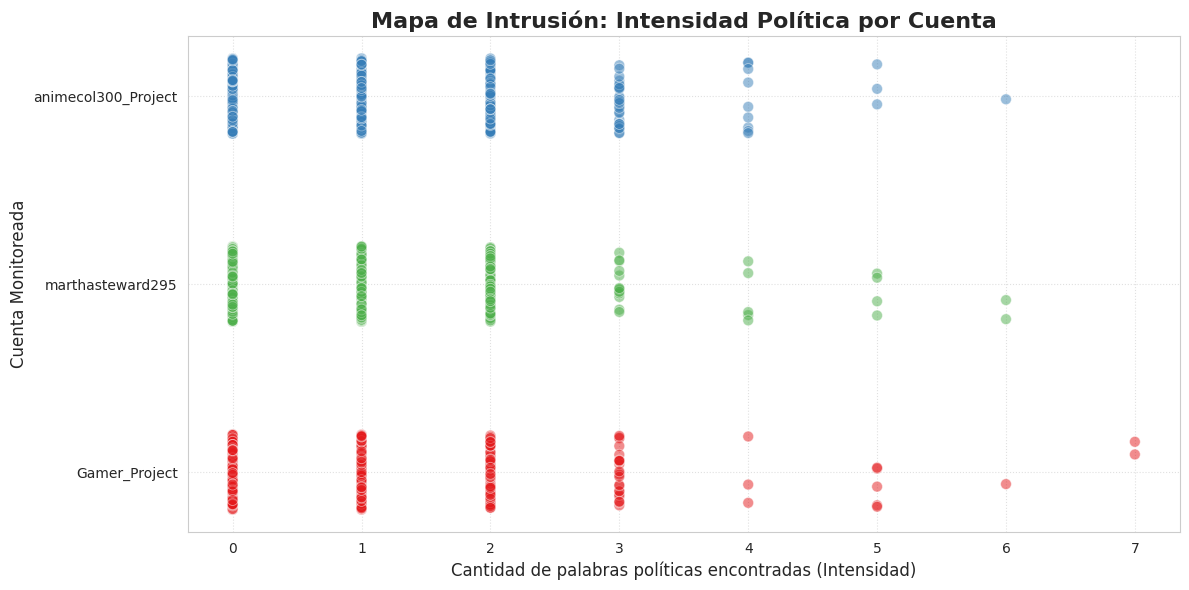


🚨 LOS 20 TWEETS CON MAYOR CARGA POLÍTICA DETECTADA:


,x_pol,palabras_pol,account_label,content
1729,7,"[trump, iran, breaking, war, ceasefire, force, history]",Gamer_Project,"BIG BREAKING: Trump’s ULTIMATE THREAT to Iran\nDonald Trump warns: if Iran even touches the ceasefire — the response will be BRUTAL, MASSIVE, and UNMATCHED in history.\n“No nukes. No games. The Strait of Hormuz STAYS OPEN — by force if necessary.”\nThis is no longer a"
8167,7,"[trump, president, military, iran, breaking, news, states]",Gamer_Project,"BREAKING: President Trump announces the Strait of Hormuz is OPENING up, and that empty ships are ""rushing"" to the US to ""LOAD UP""\n\nLFG! Big win incoming \n\n""The Fake News Media is CRAZY, or just plain CORRUPT! The United States has completely destroyed Iran’s Military,"
51,6,"[trump, israel, iran, attack, war, ceasefire]",animecol300_Project,"Urgent.. Iran announces 10 points for ceasefire after Trump's announcement.. ""Including guarantees of no further attacks on it""\n\n Guarantee of no further attacks on Iran\n\n Permanent end to the war (not a temporary ceasefire).\n\n Halt to Israeli strikes in Lebanon.\n\n"
1458,6,"[trump, government, israel, iran, news, ceasefire]",marthasteward295,Fox News: The Israeli government is NOT HAPPY with the terms of Trump’s two-week ceasefire with Iran.\n\nThis is why Israel is violating the ceasefire.
1897,6,"[israel, iran, attack, war, ceasefire, states]",animecol300_Project,"Israel Launches Massive Attack in Lebanon\n\n Israel bombed several densely populated areas in central Beirut on Wednesday afternoon without prior warning, hours after a ceasefire was announced in the war between the United States and Israel with Iran.\n\n Lebanon's Ministry"
15955,6,"[trump, president, iran, breaking, news, war]",Gamer_Project,#BREAKING: President Donald Trump has announced on Fox News that the Iran War is over
12573,5,"[israel, breaking, news, world, country]",Gamer_Project,BREAKING NEWS:\n\nThe Maldives has banned entry into the country for individuals holding Israeli passports.\n\nThe most honorable stance in the world...
3981,5,"[trump, israel, attack, breaking, ceasefire]",Gamer_Project,"BREAKING : Italian PM Giorgia Meloni exposed Trump and Netanyahu in Parliament \n\n Trump at 8:00 AM –– ""The attacks on Lebanon by Israel won't be considered violation of ceasefire"" \n\n Meloni at 8:00 PM –– ""The attack on Lebanon should just stop. Any such acts will go"
3276,5,"[army, israel, bombings, lebanese, war]",animecol300_Project,"""BACK TO THE FIELDS""\n\nBecause the adult film actress, Mia Khalifa, announced that due to Israel's bombings toward Lebanon, she will return to producing videos in order to donate her earnings to the Lebanese army."
561,5,"[israel, iran, breaking, war, ceasefire]",animecol300_Project,"BREAKING\nA ballistic missile has been launched from Iran toward central Israel.\n\nThe ceasefire clearly does not apply to Israel — tensions are still escalating, and the conflict is far from over."


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Lista Refinada de Política (corregida y limpia)
palabras_politica = [
    'trump', 'president', 'army', 'military', 'government', 'israel', 'iran', 
    'china', 'bombings', 'lebanese', 'miraflores', 'attack', 'breaking', 
    'news', 'official', 'war', 'security', 'protest', 'ceasefire', 'world', 
    'force', 'states', 'country', 'international', 'history', 'public'
]

# 2. Función de Trazabilidad (Solo Política)
def analizar_politica(texto):
    texto = str(texto).lower()
    # Buscamos las palabras exactas
    encontradas = [p for p in palabras_politica if p in texto]
    return len(encontradas), encontradas

# 3. Procesar el DataFrame
# Creamos las columnas: x_pol (el puntaje) y palabras_pol (la lista de hallazgos)
resultados = df['content'].apply(analizar_politica)
df[['x_pol', 'palabras_pol']] = pd.DataFrame(resultados.tolist(), index=df.index)

# 4. Preparar la visualización (Eje Y = Cuentas, Eje X = Score)
plt.figure(figsize=(12, 6))

# Usamos Jitter en el eje Y para que los puntos de cada cuenta no se tapen entre sí
# Pero el eje X (Score) se mantiene como el indicador de intensidad
df['y_jitter'] = df['account_label'].astype('category').cat.codes + np.random.uniform(-0.2, 0.2, size=len(df))

# Graficar
sns.scatterplot(data=df, x='x_pol', y='y_jitter', hue='account_label', 
                alpha=0.5, s=60, palette='Set1', legend=False)

# Ajustar etiquetas del eje Y para que salgan los nombres de las cuentas
plt.yticks(range(len(df['account_label'].unique())), df['account_label'].unique())

# 5. Estética de Reporte
plt.title('Mapa de Intrusión: Intensidad Política por Cuenta', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de palabras políticas encontradas (Intensidad)', fontsize=12)
plt.ylabel('Cuenta Monitoreada', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- REPORTE DE EVIDENCIA ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("\n🚨 LOS 20 TWEETS CON MAYOR CARGA POLÍTICA DETECTADA:")
# Mostramos el contenido y las palabras encontradas para que no haya duda
display(df.sort_values(by='x_pol', ascending=False)[['x_pol', 'palabras_pol', 'account_label', 'content']].head(20))

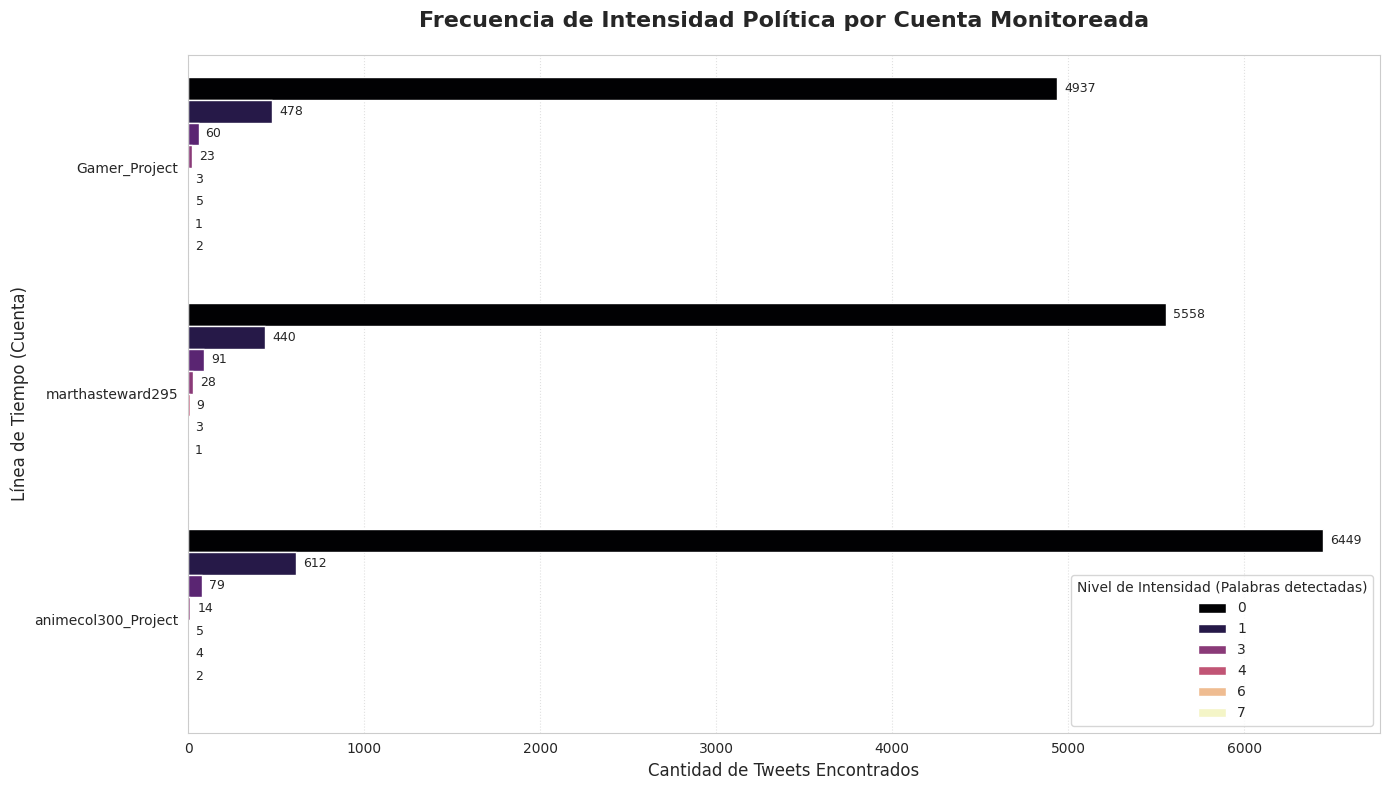


🚨 DETALLE DE LOS TWEETS CON MAYOR CARGA POLÍTICA (Top 20):


,x_pol,palabras_pol,account_label,content
1729,7,"[trump, iran, breaking, war, ceasefire, force, history]",Gamer_Project,"BIG BREAKING: Trump’s ULTIMATE THREAT to Iran\nDonald Trump warns: if Iran even touches the ceasefire — the response will be BRUTAL, MASSIVE, and UNMATCHED in history.\n“No nukes. No games. The Strait of Hormuz STAYS OPEN — by force if necessary.”\nThis is no longer a"
8167,7,"[trump, president, military, iran, breaking, news, states]",Gamer_Project,"BREAKING: President Trump announces the Strait of Hormuz is OPENING up, and that empty ships are ""rushing"" to the US to ""LOAD UP""\n\nLFG! Big win incoming \n\n""The Fake News Media is CRAZY, or just plain CORRUPT! The United States has completely destroyed Iran’s Military,"
51,6,"[trump, israel, iran, attack, war, ceasefire]",animecol300_Project,"Urgent.. Iran announces 10 points for ceasefire after Trump's announcement.. ""Including guarantees of no further attacks on it""\n\n Guarantee of no further attacks on Iran\n\n Permanent end to the war (not a temporary ceasefire).\n\n Halt to Israeli strikes in Lebanon.\n\n"
1458,6,"[trump, government, israel, iran, news, ceasefire]",marthasteward295,Fox News: The Israeli government is NOT HAPPY with the terms of Trump’s two-week ceasefire with Iran.\n\nThis is why Israel is violating the ceasefire.
1897,6,"[israel, iran, attack, war, ceasefire, states]",animecol300_Project,"Israel Launches Massive Attack in Lebanon\n\n Israel bombed several densely populated areas in central Beirut on Wednesday afternoon without prior warning, hours after a ceasefire was announced in the war between the United States and Israel with Iran.\n\n Lebanon's Ministry"
15955,6,"[trump, president, iran, breaking, news, war]",Gamer_Project,#BREAKING: President Donald Trump has announced on Fox News that the Iran War is over
12573,5,"[israel, breaking, news, world, country]",Gamer_Project,BREAKING NEWS:\n\nThe Maldives has banned entry into the country for individuals holding Israeli passports.\n\nThe most honorable stance in the world...
3981,5,"[trump, israel, attack, breaking, ceasefire]",Gamer_Project,"BREAKING : Italian PM Giorgia Meloni exposed Trump and Netanyahu in Parliament \n\n Trump at 8:00 AM –– ""The attacks on Lebanon by Israel won't be considered violation of ceasefire"" \n\n Meloni at 8:00 PM –– ""The attack on Lebanon should just stop. Any such acts will go"
3276,5,"[army, israel, bombings, lebanese, war]",animecol300_Project,"""BACK TO THE FIELDS""\n\nBecause the adult film actress, Mia Khalifa, announced that due to Israel's bombings toward Lebanon, she will return to producing videos in order to donate her earnings to the Lebanese army."
561,5,"[israel, iran, breaking, war, ceasefire]",animecol300_Project,"BREAKING\nA ballistic missile has been launched from Iran toward central Israel.\n\nThe ceasefire clearly does not apply to Israel — tensions are still escalating, and the conflict is far from over."


In [59]:
import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd

import numpy as np



# 1. Lista Refinada de Política

palabras_politica = [

    'trump', 'president', 'army', 'military', 'government', 'israel', 'iran', 

    'china', 'bombings', 'lebanese', 'miraflores', 'attack', 'breaking', 

    'news', 'official', 'war', 'security', 'protest', 'ceasefire', 'world', 

    'force', 'states', 'country', 'international', 'history', 'public'

]



# 2. Función de Trazabilidad (Solo Política)

def analizar_politica(texto):

    texto = str(texto).lower()

    encontradas = [p for p in palabras_politica if p in texto]

    return len(encontradas), encontradas



# 3. Procesar el DataFrame

resultados = df['content'].apply(analizar_politica)

df[['x_pol', 'palabras_pol']] = pd.DataFrame(resultados.tolist(), index=df.index)



# 4. Preparar la visualización: Barras Horizontales Agrupadas

plt.figure(figsize=(14, 8))



# Creamos el gráfico: Y es la cuenta, X es el conteo automático de tweets, 

# y 'hue' (el color) es el nivel de intensidad x_pol

ax = sns.countplot(data=df, y='account_label', hue='x_pol', palette='magma')



# 5. Estética de Reporte

plt.title('Frecuencia de Intensidad Política por Cuenta Monitoreada', fontsize=16, fontweight='bold', pad=20)

plt.xlabel('Cantidad de Tweets Encontrados', fontsize=12)

plt.ylabel('Línea de Tiempo (Cuenta)', fontsize=12)

plt.legend(title="Nivel de Intensidad (Palabras detectadas)", loc='lower right')

plt.grid(axis='x', linestyle=':', alpha=0.6)



# 6. Añadir etiquetas de cantidad sobre las barras para precisión

for p in ax.patches:

    width = p.get_width()

    if width > 0: # Solo mostrar si hay datos

        ax.annotate(f'{int(width)}', 

                    (p.get_width(), p.get_y() + p.get_height() / 2.), 

                    va='center', ha='left', 

                    xytext=(5, 0), 

                    textcoords='offset points', 

                    fontsize=9)



plt.tight_layout()

plt.show()



# --- REPORTE DE EVIDENCIA ---

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)



print("\n🚨 DETALLE DE LOS TWEETS CON MAYOR CARGA POLÍTICA (Top 20):")

display(df.sort_values(by='x_pol', ascending=False)[['x_pol', 'palabras_pol', 'account_label', 'content']].head(20))

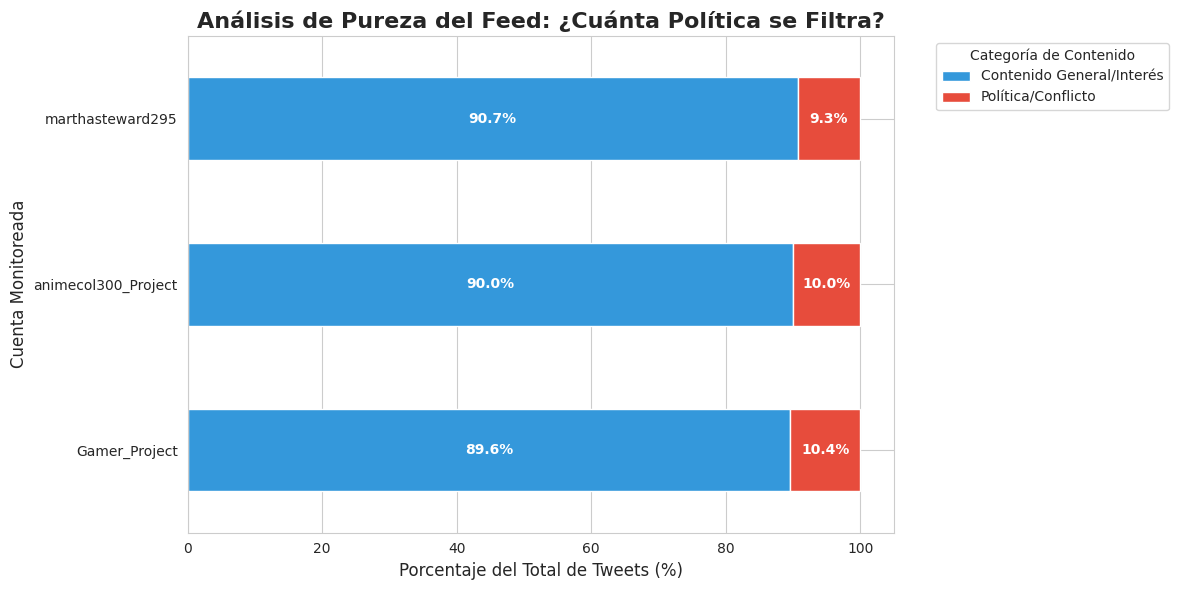


📝 RESUMEN EJECUTIVO PARA EL ARTÍCULO:
- La cuenta Gamer_Project tiene un 10.38% de contenido político infiltrado.
- La cuenta animecol300_Project tiene un 9.99% de contenido político infiltrado.
- La cuenta marthasteward295 tiene un 9.33% de contenido político infiltrado.


In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clasificamos los tweets: Políticos vs. Resto
df['categoria'] = df['x_pol'].apply(lambda x: 'Política/Conflicto' if x > 0 else 'Contenido General/Interés')

# 2. Creamos la tabla de porcentajes por cuenta
resumen = pd.crosstab(df['account_label'], df['categoria'], normalize='index') * 100

# 3. Graficamos las barras apiladas
ax = resumen.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#3498db', '#e74c3c'])

# 4. Estética de Reporte Profesional
plt.title('Análisis de Pureza del Feed: ¿Cuánta Política se Filtra?', fontsize=16, fontweight='bold')
plt.xlabel('Porcentaje del Total de Tweets (%)', fontsize=12)
plt.ylabel('Cuenta Monitoreada', fontsize=12)
plt.legend(title='Categoría de Contenido', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Añadir los porcentajes dentro de las barras para máxima claridad
for p in ax.patches:
    width = p.get_width()
    if width > 5: # Solo mostrar si el segmento es lo suficientemente grande
        ax.annotate(f'{width:.1f}%', 
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# --- REPORTE COMPLEMENTARIO ---
print("\n📝 RESUMEN EJECUTIVO PARA EL ARTÍCULO:")
for cuenta in resumen.index:
    pct_pol = resumen.loc[cuenta, 'Política/Conflicto']
    print(f"- La cuenta {cuenta} tiene un {pct_pol:.2f}% de contenido político infiltrado.")

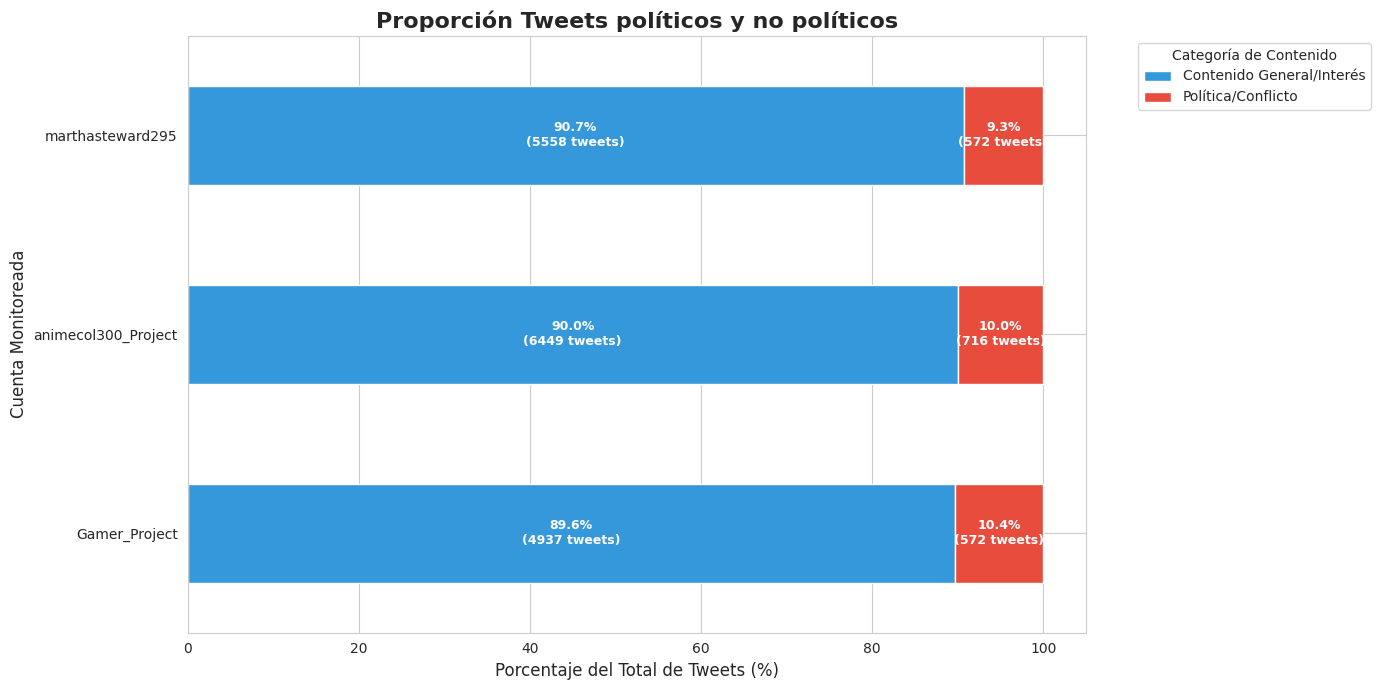


📝 DATOS PARA EL CÁLCULO DE LAMBDA (POISSON):
- Gamer_Project: 572 políticos de 5509 totales. Lambda (λ) para 100 tweets: 10.38
- animecol300_Project: 716 políticos de 7165 totales. Lambda (λ) para 100 tweets: 9.99
- marthasteward295: 572 políticos de 6130 totales. Lambda (λ) para 100 tweets: 9.33


In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clasificamos los tweets: Políticos vs. Resto
df['categoria'] = df['x_pol'].apply(lambda x: 'Política/Conflicto' if x > 0 else 'Contenido General/Interés')

# 2. Creamos dos tablas: una de porcentajes y otra de conteos absolutos
resumen_pct = pd.crosstab(df['account_label'], df['categoria'], normalize='index') * 100
resumen_abs = pd.crosstab(df['account_label'], df['categoria'])

# 3. Graficamos las barras apiladas usando la tabla de porcentajes
ax = resumen_pct.plot(kind='barh', stacked=True, figsize=(14, 7), color=['#3498db', '#e74c3c'])

# 4. Estética de Reporte Profesional
plt.title('Proporción Tweets políticos y no políticos', fontsize=16, fontweight='bold')
plt.xlabel('Porcentaje del Total de Tweets (%)', fontsize=12)
plt.ylabel('Cuenta Monitoreada', fontsize=12)
plt.legend(title='Categoría de Contenido', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Añadir etiquetas: Porcentaje + (Cantidad de tweets)
for i, cuenta in enumerate(resumen_pct.index):
    # Valores para Contenido General (Azul)
    pct_gen = resumen_pct.loc[cuenta, 'Contenido General/Interés']
    abs_gen = resumen_abs.loc[cuenta, 'Contenido General/Interés']
    
    # Valores para Política (Rojo)
    pct_pol = resumen_pct.loc[cuenta, 'Política/Conflicto']
    abs_pol = resumen_abs.loc[cuenta, 'Política/Conflicto']
    
    # Colocar etiqueta en la sección azul
    if pct_gen > 5:
        plt.text(pct_gen / 2, i, f'{pct_gen:.1f}%\n({abs_gen} tweets)', 
                 ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Colocar etiqueta en la sección roja
    if pct_pol > 5:
        plt.text(pct_gen + (pct_pol / 2), i, f'{pct_pol:.1f}%\n({abs_pol} tweets)', 
                 ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# --- REPORTE TÉCNICO COMPLEMENTARIO ---
print("\n📝 DATOS PARA EL CÁLCULO DE LAMBDA (POISSON):")
for cuenta in resumen_abs.index:
    total = resumen_abs.loc[cuenta].sum()
    politicos = resumen_abs.loc[cuenta, 'Política/Conflicto']
    lmbda = (politicos / total) * 100
    print(f"- {cuenta}: {politicos} políticos de {total} totales. Lambda (λ) para 100 tweets: {lmbda:.2f}")

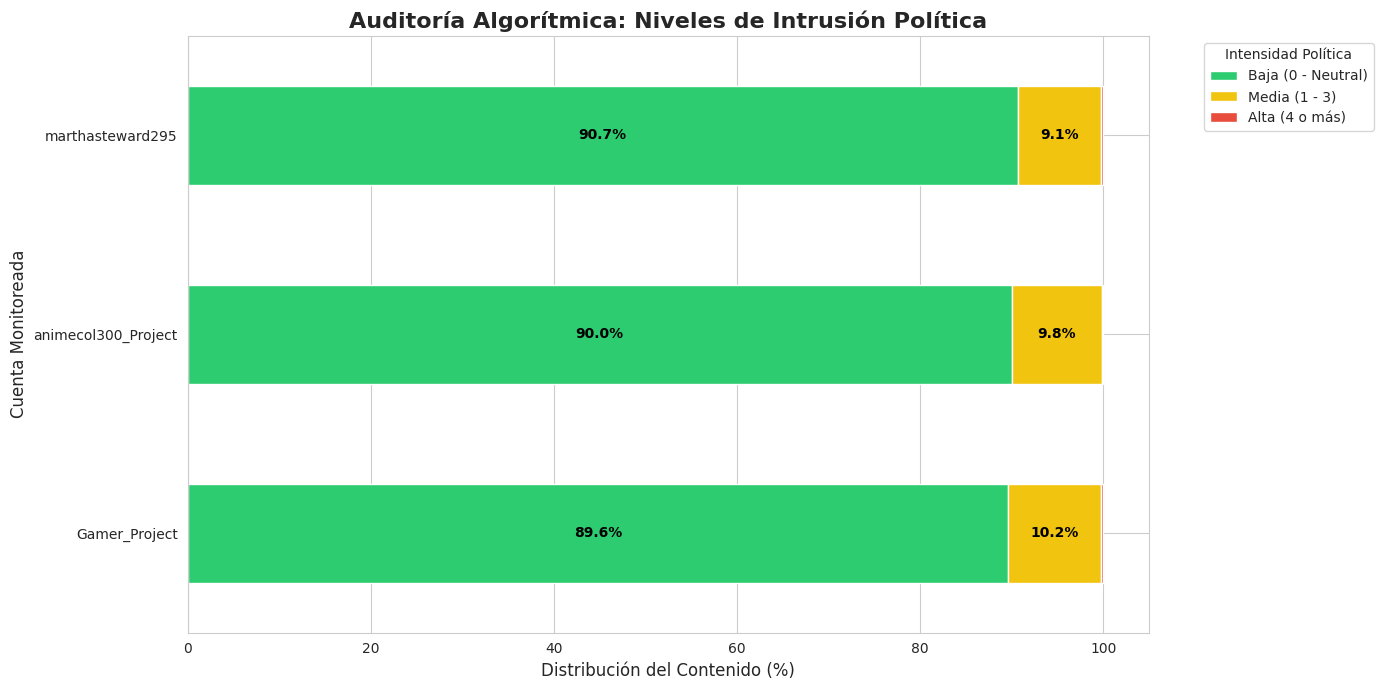


📊 DATOS CLAVE PARA EL ARTÍCULO:
- En la cuenta 'Gamer_Project', el 10.38% del contenido ya presenta algún grado de carga política.
- En la cuenta 'animecol300_Project', el 9.99% del contenido ya presenta algún grado de carga política.
- En la cuenta 'marthasteward295', el 9.33% del contenido ya presenta algún grado de carga política.


In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Tu lista de "Petróleo" Político 2.0
palabras_politica = [
    'trump', 'president', 'army', 'military', 'government', 'israel', 'iran', 
    'china', 'bombings', 'lebanese', 'miraflores', 'attack', 'breaking', 
    'news', 'official', 'war', 'security', 'protest', 'ceasefire', 'world', 
    'force', 'states', 'country', 'international', 'history', 'public'
]

# 2. Nueva función de clasificación basada en tus rangos
def clasificar_intensidad(texto):
    texto = str(texto).lower()
    score = sum(1 for p in palabras_politica if p in texto)
    
    if score == 0:
        return 'Baja (0 - Neutral)'
    elif 1 <= score <= 3:
        return 'Media (1 - 3)'
    else:
        return 'Alta (4 o más)'

# 3. Aplicamos la clasificación al DataFrame
df['rango_politico'] = df['content'].apply(clasificar_intensidad)

# 4. Creamos la tabla de proporciones (Porcentaje por cuenta)
# Ordenamos las categorías para que la leyenda sea lógica
orden_categorias = ['Baja (0 - Neutral)', 'Media (1 - 3)', 'Alta (4 o más)']
resumen_detalle = pd.crosstab(df['account_label'], df['rango_politico'], normalize='index') * 100
resumen_detalle = resumen_detalle[orden_categorias]

# 5. Graficamos el Stacked Bar Chart
ax = resumen_detalle.plot(kind='barh', stacked=True, figsize=(14, 7), 
                          color=['#2ecc71', '#f1c40f', '#e74c3c']) # Verde, Amarillo, Rojo

# 6. Estética y Etiquetas de Datos
plt.title('Auditoría Algorítmica: Niveles de Intrusión Política', fontsize=16, fontweight='bold')
plt.xlabel('Distribución del Contenido (%)', fontsize=12)
plt.ylabel('Cuenta Monitoreada', fontsize=12)
plt.legend(title='Intensidad Política', bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir los porcentajes dentro de las barras
for p in ax.patches:
    width = p.get_width()
    if width > 3: # Solo mostrar si el segmento es visible
        ax.annotate(f'{width:.1f}%', 
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', color='black', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- REPORTE TÉCNICO PARA ANDRÉS ---
print("\n📊 DATOS CLAVE PARA EL ARTÍCULO:")
for cuenta in resumen_detalle.index:
    media_alta = resumen_detalle.loc[cuenta, 'Media (1 - 3)'] + resumen_detalle.loc[cuenta, 'Alta (4 o más)']
    print(f"- En la cuenta '{cuenta}', el {media_alta:.2f}% del contenido ya presenta algún grado de carga política.")

In [63]:
from scipy.stats import poisson



# 1. Calculamos el promedio real de tweets de alta política (Score >= 4)

# para la cuenta Gamer

tweets_gamer = df[df['account_label'] == 'Gamer_Project']

total_tweets = len(tweets_gamer)

tweets_intrusivos = len(tweets_gamer[tweets_gamer['x_pol'] >= 4])



# Lambda (λ) = promedio de eventos por tweet

# Para hacerlo por "scroll de 10", multiplicamos por 10

lambda_gamer = (tweets_intrusivos / total_tweets) * 20



print(f"📈 El Lambda (λ) para la cuenta Gamer es: {lambda_gamer:.2f}")

print(f"Esto significa que en cada 10 tweets, Andrés se encuentra con {lambda_gamer:.2f} 'bombas' políticas.\n")



# 2. ¿Cuál es la probabilidad de que NO haya política en un scroll? P(k=0)

prob_cero = poisson.pmf(k=0, mu=lambda_gamer) * 100



print(f"💡 Según la estadística de Poisson:")

print(f"- Probabilidad de un scroll 100% limpio: {prob_cero:.2f}%")

print(f"- Probabilidad de sufrir al menos 1 intrusión política: {100 - prob_cero:.2f}%")

📈 El Lambda (λ) para la cuenta Gamer es: 0.02
Esto significa que en cada 10 tweets, Andrés se encuentra con 0.02 'bombas' políticas.

💡 Según la estadística de Poisson:
- Probabilidad de un scroll 100% limpio: 98.02%
- Probabilidad de sufrir al menos 1 intrusión política: 1.98%
